In [1]:
# ============================================================
# 0. Install dependencies (run once per session)
# ============================================================
!pip install -q open_clip_torch timm

# ============================================================
# 1. Imports & basic config
# ============================================================
import os
import random
from pathlib import Path
from typing import List, Tuple

import numpy as np
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split

import open_clip

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)
print("GPU count:", torch.cuda.device_count())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 23.0 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 5.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 108.0 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 77.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 57.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 30.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 15.0 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 2.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 57.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━

/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

Device: cuda
GPU count: 2


In [4]:
# ============================================================
# 2. Locate dataset
#    (adjust DATA_ROOT if needed after printing structure)
# ============================================================
DATA_ROOT = Path("/kaggle/input/sign-language-gesture-images-dataset")

print("Top-level contents:")
for p in DATA_ROOT.iterdir():
    print(" ", p)

# Many Kaggle image datasets use a single subfolder that
# contains class folders. We'll auto-detect the 'deepest'
# folder that has subdirectories = classes.

def find_image_root(root: Path) -> Path:
    candidates = []
    for dirpath, dirnames, filenames in os.walk(root):
        dirpath = Path(dirpath)
        # Heuristic: this directory has subdirs and mostly image files inside subdirs
        if len(dirnames) > 0:
            candidates.append(dirpath)
    # Choose the deepest candidate (longest path)
    if not candidates:
        return root
    candidates = sorted(candidates, key=lambda p: len(str(p)))
    return candidates[-1]

IMAGE_ROOT = find_image_root(DATA_ROOT)
print("\nAssumed IMAGE_ROOT:", IMAGE_ROOT)

print("\nClass folders under IMAGE_ROOT:")
class_dirs = sorted([d for d in IMAGE_ROOT.iterdir() if d.is_dir()])
for d in class_dirs:
    print(" ", d.name)

# ============================================================
# 3. Dataset class
# ============================================================

class SignLanguageDataset(Dataset):
    def __init__(self, root: Path, preprocess, max_per_class: int = None):
        """
        root: directory whose subfolders are class names.
        preprocess: CLIP preprocess (PIL Image -> tensor).
        max_per_class: optional cap per class for faster experiments.
        """
        self.root = Path(root)
        self.preprocess = preprocess

        self.classes = sorted([d.name for d in self.root.iterdir() if d.is_dir()])
        self.class_to_idx = {c: i for i, c in enumerate(self.classes)}

        self.samples: List[Tuple[str, int]] = []
        for cls in self.classes:
            folder = self.root / cls
            imgs = [p for p in folder.glob("*") if p.suffix.lower() in [".jpg", ".jpeg", ".png", ".bmp", ".webp"]]
            imgs = sorted(imgs)
            if max_per_class is not None:
                imgs = imgs[:max_per_class]
            for img_path in imgs:
                self.samples.append((str(img_path), self.class_to_idx[cls]))

        print(f"Found {len(self.samples)} images across {len(self.classes)} classes.")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("RGB")
        img = self.preprocess(img)
        return img, label

# ============================================================
# 4. Load CLIP model (ViT-B/32) and set up DataParallel
# ============================================================
print("\nLoading CLIP model...")
model, _, preprocess = open_clip.create_model_and_transforms(
    "ViT-B-32",
    pretrained="laion2b_s34b_b79k"
)
tokenizer = open_clip.get_tokenizer("ViT-B-32")

model.eval()
model.to(device)

# Use both GPUs if available
if torch.cuda.device_count() > 1:
    print("Using DataParallel over", torch.cuda.device_count(), "GPUs")
    model = nn.DataParallel(model)

# ============================================================
# 5. Build dataset & splits
# ============================================================
MAX_PER_CLASS = None  # set e.g. 300 if you want faster runs

full_dataset = SignLanguageDataset(IMAGE_ROOT, preprocess, max_per_class=MAX_PER_CLASS)

# 80% / 10% / 10% split (for reference, although we only need test for zero-shot)
train_ratio, val_ratio = 0.8, 0.1
total_len = len(full_dataset)
train_len = int(total_len * train_ratio)
val_len   = int(total_len * val_ratio)
test_len  = total_len - train_len - val_len

train_ds, val_ds, test_ds = random_split(
    full_dataset,
    [train_len, val_len, test_len],
    generator=torch.Generator().manual_seed(SEED)
)

print(f"\nDataset sizes -> Train: {len(train_ds)}, Val: {len(val_ds)}, Test: {len(test_ds)}")

BATCH_SIZE = 128

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

# ============================================================
# 6. Create text prompts for zero-shot
# ============================================================

# ============================================================
# 6. Create *better* text prompts for zero-shot (prompt ensemble)
# ============================================================

def build_prompts_for_class(class_name: str):
    """
    Return a LIST of prompts for this class.
    We embed them all and average their text features.
    """
    raw = class_name.strip()

    # Map "_" to a meaningful word
    if raw == "_":
        concept = "space"
    else:
        concept = raw

    prompts = []

    if len(raw) == 1 and raw.isalpha():
        # Letter
        letter = raw.upper()
        prompts.extend([
            f"a high-contrast black and white image of a single hand showing the American Sign Language alphabet letter '{letter}' on a black background",
            f"a grayscale image of a right hand making the sign for the letter '{letter}' in American Sign Language, centered on a dark background",
            f"a simple black background with a white hand gesture representing the ASL letter '{letter}'",
            f"a clear image of a static hand pose for the American Sign Language letter '{letter}'",
        ])
    elif raw.isdigit():
        # Digit
        digit = raw
        prompts.extend([
            f"a high-contrast black and white image of a single hand showing the American Sign Language digit '{digit}' on a black background",
            f"a grayscale image of a right hand making the sign for the number '{digit}' in sign language, centered on a dark background",
            f"a simple black background with a white hand gesture representing the sign language digit '{digit}'",
            f"a clear image of a static hand pose for the sign language number '{digit}'",
        ])
    elif raw == "_":
        # Space sign
        prompts.extend([
            "a high-contrast black and white image of a single hand showing the American Sign Language sign for space between words on a black background",
            "a grayscale image of a right hand making the ASL gesture meaning space or blank, centered on a dark background",
            "a simple black background with a white hand gesture representing the sign language symbol for space",
            "a clear image of a static hand pose that means space in sign language",
        ])
    else:
        # Fallback for any weird class names
        prompts.extend([
            f"a high-contrast black and white image of a single hand showing the sign language gesture for '{concept}' on a black background",
            f"a grayscale image of a right hand making the sign language gesture for '{concept}', centered on a dark background",
        ])

    return prompts

classes = full_dataset.classes
print("\nClasses (folder names):")
for c in classes:
    print(" ", c)

# Show example prompt set for one or two classes
print("\nExample prompt set for class 'A' (if exists):")
if "A" in classes:
    for p in build_prompts_for_class("A"):
        print("  -", p)

# ============================================================
# 7. Encode text prompts with ensembling
# ============================================================
print("\nEncoding text prompts with ensembling...")

all_text_features = []

with torch.no_grad():
    for cls in classes:
        prompts = build_prompts_for_class(cls)
        tokens = tokenizer(prompts).to(device)

        if isinstance(model, nn.DataParallel):
            feats = model.module.encode_text(tokens)
        else:
            feats = model.encode_text(tokens)

        # Average over prompts for this class
        feats = feats / feats.norm(dim=-1, keepdim=True)
        cls_feat = feats.mean(dim=0)
        cls_feat = cls_feat / cls_feat.norm(dim=-1, keepdim=True)

        all_text_features.append(cls_feat.unsqueeze(0))

    text_features = torch.cat(all_text_features, dim=0)  # (num_classes, dim)

print("Ensembled text feature shape:", text_features.shape)


# ============================================================
# 8. Zero-shot evaluation helper
# ============================================================
from collections import defaultdict

@torch.no_grad()
def evaluate_zero_shot(dataloader, split_name="Test"):
    model.eval()
    total = 0
    correct = 0

    per_class_total = defaultdict(int)
    per_class_correct = defaultdict(int)

    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)

        if isinstance(model, nn.DataParallel):
            image_features = model.module.encode_image(images)
        else:
            image_features = model.encode_image(images)

        image_features = image_features / image_features.norm(dim=-1, keepdim=True)

        # Similarity logits (cosine, scaled)
        logits = image_features @ text_features.T  # (batch, num_classes)

        preds = logits.argmax(dim=-1)

        total += labels.size(0)
        correct += (preds == labels).sum().item()

        for y, yhat in zip(labels.tolist(), preds.tolist()):
            per_class_total[y] += 1
            if y == yhat:
                per_class_correct[y] += 1

    overall_acc = correct / total if total > 0 else 0.0
    print(f"\n[{split_name}] Zero-shot accuracy: {overall_acc*100:.2f}%  ({correct}/{total})")

    print(f"\n[{split_name}] Per-class accuracy:")
    for idx, cls_name in enumerate(classes):
        if per_class_total[idx] == 0:
            acc = 0.0
        else:
            acc = per_class_correct[idx] / per_class_total[idx]
        print(f"  {cls_name:10s} -> {acc*100:5.1f}%  ({per_class_correct[idx]}/{per_class_total[idx]})")

    return overall_acc

# ============================================================
# 9. Run zero-shot evaluation
#    (main focus: test set; you can also check val/train for curiosity)
# ============================================================

_ = evaluate_zero_shot(test_loader, split_name="Test")

# (Optional) also check validation:
_ = evaluate_zero_shot(val_loader, split_name="Val")

Top-level contents:
  /kaggle/input/sign-language-gesture-images-dataset/Gesture Image Pre-Processed Data
  /kaggle/input/sign-language-gesture-images-dataset/Gesture Image Data

Assumed IMAGE_ROOT: /kaggle/input/sign-language-gesture-images-dataset/Gesture Image Pre-Processed Data

Class folders under IMAGE_ROOT:
  0
  1
  2
  3
  4
  5
  6
  7
  8
  9
  A
  B
  C
  D
  E
  F
  G
  H
  I
  J
  K
  L
  M
  N
  O
  P
  Q
  R
  S
  T
  U
  V
  W
  X
  Y
  Z
  _

Loading CLIP model...
Using DataParallel over 2 GPUs
Found 55500 images across 37 classes.

Dataset sizes -> Train: 44400, Val: 5550, Test: 5550

Classes (folder names):
  0
  1
  2
  3
  4
  5
  6
  7
  8
  9
  A
  B
  C
  D
  E
  F
  G
  H
  I
  J
  K
  L
  M
  N
  O
  P
  Q
  R
  S
  T
  U
  V
  W
  X
  Y
  Z
  _

Example prompt set for class 'A' (if exists):
  - a high-contrast black and white image of a single hand showing the American Sign Language alphabet letter 'A' on a black background
  - a grayscale image of a right h

In [5]:
# ============================================================
# 11. Supervised classifier on top of frozen CLIP image encoder
# ============================================================
import torch.nn.functional as F
from tqdm.auto import tqdm

# We'll use the dimensionality of the CLIP embeddings we already computed
EMBED_DIM = text_features.shape[1]  # typically 512
NUM_CLASSES = len(classes)

# Get the underlying CLIP model (in case it's inside DataParallel)
if isinstance(model, nn.DataParallel):
    clip_backbone = model.module
else:
    clip_backbone = model

# Freeze CLIP backbone parameters
for p in clip_backbone.parameters():
    p.requires_grad = False

class ClipImageClassifier(nn.Module):
    def __init__(self, clip_model, embed_dim, num_classes):
        super().__init__()
        self.clip_model = clip_model
        self.fc = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        # We don't want gradients through CLIP model
        with torch.no_grad():
            feats = self.clip_model.encode_image(x)  # (B, embed_dim)
        feats = feats / feats.norm(dim=-1, keepdim=True)
        # Detach so CLIP never trains, only the head
        feats = feats.detach()
        logits = self.fc(feats)
        return logits

classifier = ClipImageClassifier(clip_backbone, EMBED_DIM, NUM_CLASSES).to(device)

# Use both GPUs if available
if torch.cuda.device_count() > 1:
    print("Using DataParallel for classifier over", torch.cuda.device_count(), "GPUs")
    classifier = nn.DataParallel(classifier)

# Only optimize the linear head parameters
if isinstance(classifier, nn.DataParallel):
    head_params = classifier.module.fc.parameters()
else:
    head_params = classifier.fc.parameters()

optimizer = torch.optim.AdamW(head_params, lr=1e-3, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()

scaler = torch.cuda.amp.GradScaler(enabled=(device == "cuda"))

# ============================================================
# 12. Training and evaluation loops
# ============================================================

def train_one_epoch(cls_model, loader, optimizer, scaler, epoch):
    cls_model.train()
    running_loss = 0.0
    running_correct = 0
    total = 0

    pbar = tqdm(loader, desc=f"Train Epoch {epoch}", leave=False)
    for images, labels in pbar:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast(enabled=(device == "cuda")):
            logits = cls_model(images)
            loss = criterion(logits, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        preds = logits.argmax(dim=1)
        correct = (preds == labels).sum().item()

        batch_size = labels.size(0)
        total += batch_size
        running_correct += correct
        running_loss += loss.item() * batch_size

        pbar.set_postfix({
            "loss": f"{running_loss / total:.4f}",
            "acc": f"{100.0 * running_correct / total:.2f}%"
        })

    epoch_loss = running_loss / total
    epoch_acc = running_correct / total
    return epoch_loss, epoch_acc

@torch.no_grad()
def eval_classifier(cls_model, loader, split_name="Val"):
    cls_model.eval()
    running_loss = 0.0
    running_correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        with torch.cuda.amp.autocast(enabled=(device == "cuda")):
            logits = cls_model(images)
            loss = criterion(logits, labels)

        preds = logits.argmax(dim=1)
        correct = (preds == labels).sum().item()

        batch_size = labels.size(0)
        total += batch_size
        running_correct += correct
        running_loss += loss.item() * batch_size

    epoch_loss = running_loss / total
    epoch_acc = running_correct / total
    print(f"[{split_name}] Loss: {epoch_loss:.4f} | Acc: {epoch_acc*100:.2f}% ({running_correct}/{total})")
    return epoch_loss, epoch_acc

# ============================================================
# 13. Run training
# ============================================================

EPOCHS = 10              # you can increase if needed
best_val_acc = 0.0
best_state = None

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(classifier, train_loader, optimizer, scaler, epoch)
    print(f"Epoch {epoch}: Train Loss={train_loss:.4f}, Train Acc={train_acc*100:.2f}%")

    val_loss, val_acc = eval_classifier(classifier, val_loader, split_name="Val")

    # Save best model by validation accuracy
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        if isinstance(classifier, nn.DataParallel):
            best_state = classifier.module.state_dict()
        else:
            best_state = classifier.state_dict()
        print(f"  -> New best val acc: {best_val_acc*100:.2f}% (saving state)")

# Load best weights before final test
if best_state is not None:
    if isinstance(classifier, nn.DataParallel):
        classifier.module.load_state_dict(best_state)
    else:
        classifier.load_state_dict(best_state)

print("\nFinal evaluation on TEST set with best model:")
_ = eval_classifier(classifier, test_loader, split_name="Test")


Using DataParallel for classifier over 2 GPUs


/tmp/ipykernel_47/2996129360.py:53: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(device == "cuda"))


Train Epoch 1:   0%|          | 0/347 [00:00<?, ?it/s]

/tmp/ipykernel_47/2996129360.py:72: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device == "cuda")):


Epoch 1: Train Loss=3.1363, Train Acc=75.38%


...

[Val] Loss: 2.6997 | Acc: 92.00% (5106/5550)
  -> New best val acc: 92.00% (saving state)


Train Epoch 2:   0%|          | 0/347 [00:00<?, ?it/s]

Epoch 2: Train Loss=2.3370, Train Acc=93.08%
[Val] Loss: 2.0123 | Acc: 94.36% (5237/5550)
  -> New best val acc: 94.36% (saving state)


Train Epoch 3:   0%|          | 0/347 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [5]:
from collections import defaultdict

@torch.no_grad()
def eval_classifier_detailed(cls_model, loader, classes, split_name="Test"):
    cls_model.eval()
    total = 0
    correct = 0

    per_class_total = defaultdict(int)
    per_class_correct = defaultdict(int)

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        with torch.cuda.amp.autocast(enabled=(device == "cuda")):
            logits = cls_model(images)

        preds = logits.argmax(dim=1)

        batch_size = labels.size(0)
        total += batch_size
        correct += (preds == labels).sum().item()

        for y, yhat in zip(labels.tolist(), preds.tolist()):
            per_class_total[y] += 1
            if y == yhat:
                per_class_correct[y] += 1

    overall_acc = correct / total if total > 0 else 0.0
    print(f"\n[{split_name}] Accuracy: {overall_acc*100:.2f}%  ({correct}/{total})")

    print(f"\n[{split_name}] Per-class accuracy:")
    for idx, cls_name in enumerate(classes):
        if per_class_total[idx] == 0:
            acc = 0.0
        else:
            acc = per_class_correct[idx] / per_class_total[idx]
        print(f"  {cls_name:10s} -> {acc*100:5.1f}%  ({per_class_correct[idx]}/{per_class_total[idx]})")

    return overall_acc

# Make sure best weights are loaded (as in previous code)
if best_state is not None:
    if isinstance(classifier, nn.DataParallel):
        classifier.module.load_state_dict(best_state)
    else:
        classifier.load_state_dict(best_state)

# 🔥 Final detailed test (same style as zero-shot logs)
_ = eval_classifier_detailed(classifier, test_loader, classes, split_name="Test")


/tmp/ipykernel_47/1438435941.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device == "cuda")):



[Test] Accuracy: 96.86%  (5376/5550)

[Test] Per-class accuracy:
  0          -> 100.0%  (133/133)
  1          -> 100.0%  (135/135)
  2          ->  97.7%  (127/130)
  3          ->  97.2%  (138/142)
  4          ->  89.8%  (114/127)
  5          ->  95.1%  (135/142)
  6          ->  97.2%  (140/144)
  7          ->  97.9%  (142/145)
  8          -> 100.0%  (150/150)
  9          ->  98.9%  (176/178)
  A          ->  99.3%  (143/144)
  B          -> 100.0%  (172/172)
  C          -> 100.0%  (126/126)
  D          ->  90.2%  (129/143)
  E          ->  99.3%  (144/145)
  F          ->  85.2%  (132/155)
  G          ->  83.9%  (120/143)
  H          ->  89.4%  (144/161)
  I          ->  97.6%  (166/170)
  J          ->  99.3%  (140/141)
  K          ->  94.9%  (149/157)
  L          ->  99.4%  (167/168)
  M          ->  95.8%  (137/143)
  N          ->  98.6%  (145/147)
  O          -> 100.0%  (141/141)
  P          ->  94.8%  (146/154)
  Q          -> 100.0%  (148/148)
  R          -> 


Showing a few prediction examples from the TEST set (TRAINED CLASSIFIER)...


/tmp/ipykernel_47/987446447.py:15: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device == "cuda")):


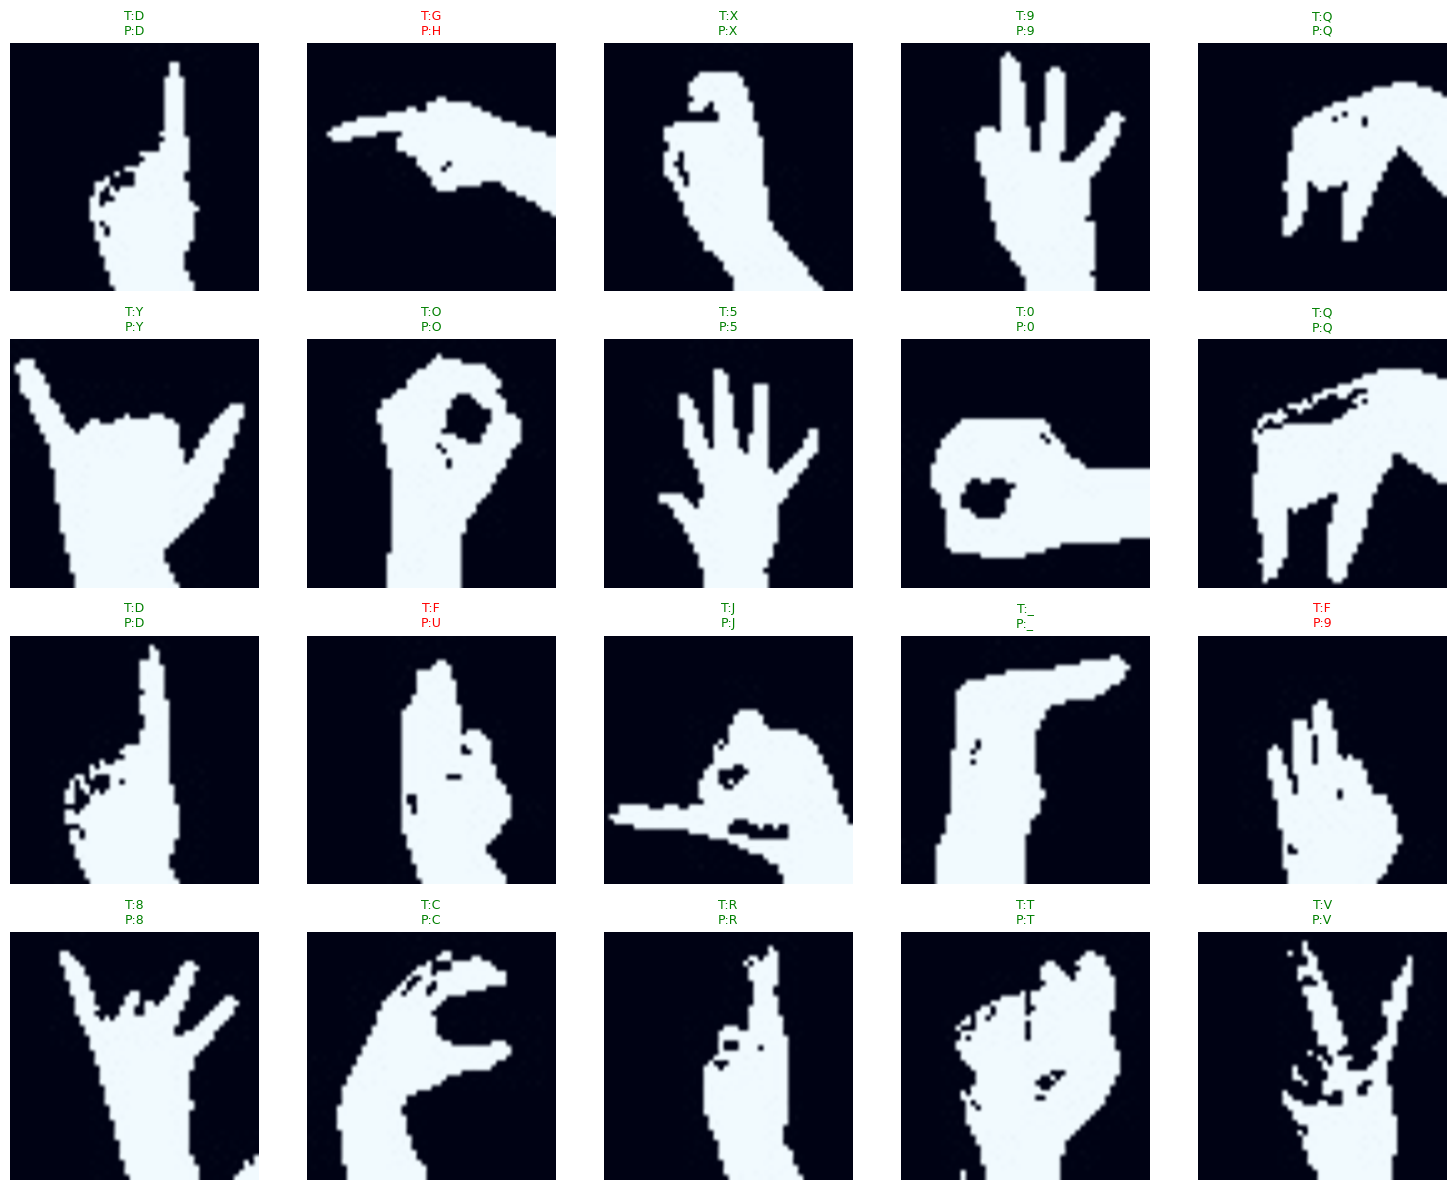

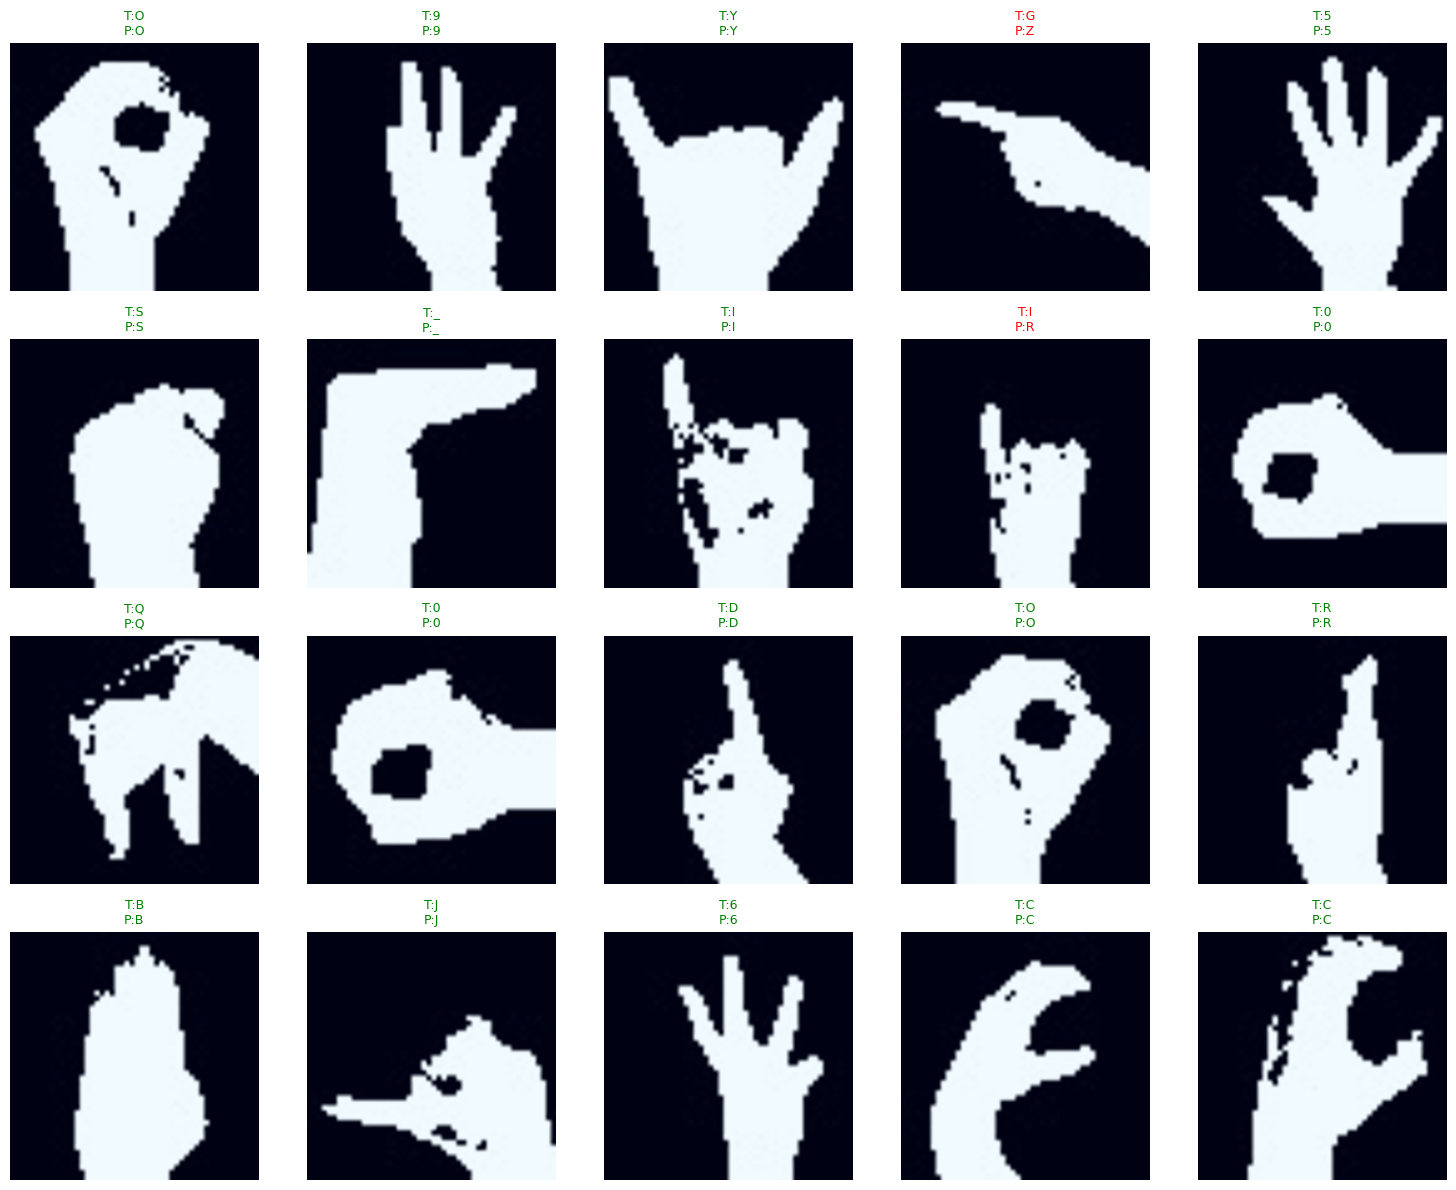

In [6]:
# ============================================================
# 10. Show a few qualitative examples (TRAINED CLASSIFIER)
# ============================================================
import matplotlib.pyplot as plt

def show_examples_classifier(dataloader, num_batches=1):
    classifier.eval()
    shown = 0
    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            # Forward through the trained classifier (linear head on CLIP)
            with torch.cuda.amp.autocast(enabled=(device == "cuda")):
                logits = classifier(images)
            preds = logits.argmax(dim=-1)

            images_np = images.cpu().permute(0, 2, 3, 1).numpy()
            labels_np = labels.cpu().numpy()
            preds_np  = preds.cpu().numpy()

            batch_size = images_np.shape[0]
            cols = 5
            rows = min(4, (batch_size + cols - 1) // cols)
            plt.figure(figsize=(3*cols, 3*rows))

            for i in range(min(batch_size, rows*cols)):
                plt.subplot(rows, cols, i+1)
                # CLIP preprocess outputs normalized tensors; we just rescale for display
                img = images_np[i]
                img = (img - img.min()) / (img.max() - img.min() + 1e-6)
                plt.imshow(img)

                true_cls = classes[labels_np[i]]
                pred_cls = classes[preds_np[i]]

                title = f"T:{true_cls}\nP:{pred_cls}"
                color = "green" if true_cls == pred_cls else "red"
                plt.title(title, color=color, fontsize=9)
                plt.axis("off")

            plt.tight_layout()
            plt.show()

            shown += 1
            if shown >= num_batches:
                break

print("\nShowing a few prediction examples from the TEST set (TRAINED CLASSIFIER)...")
show_examples_classifier(test_loader, num_batches=2)


In [7]:
# Save full classifier + frozen CLIP
save_path = "/kaggle/working/sign_classifier.pt"

if isinstance(classifier, nn.DataParallel):
    torch.save(classifier.module.state_dict(), save_path)
else:
    torch.save(classifier.state_dict(), save_path)

print("Saved PyTorch model:", save_path)


Saved PyTorch model: /kaggle/working/sign_classifier.pt
